# Step 1 -- PCA background basis test

Exercises `pca_background.py` (this folder). Builds a PCA background dictionary
{ mu, V } from the last N = 10 snapshots of the MiHI cube, then inspects the basis:
explained variance, eigenprofiles, reconstruction quality vs K, and the autograd
path that step 2 will optimise.

Run order: **config -> load -> fit -> diagnostics**. The **self-test** cell at the
bottom needs no external data, so it can be run on its own to validate the module.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# pca_background.py lives in this folder (develop/)
from pca_background import fit_background_basis, PCABackground

%load_ext autoreload
%autoreload 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

device: cpu


In [4]:
# ---- configuration --------------------------------------------------
N     = 10                # number of trailing snapshots that form the background set
K     = 10                # active number of PCA components (change later via pca.set_n_components)
LAM   = slice(100, 500)   # wavelength crop  -- same as the fit
YS    = slice(15, -15)    # spatial crop (y) -- same as the fit
XS    = slice(15, -15)    # spatial crop (x) -- same as the fit

# Which spectra define the "background"? YOU choose the input here:
#   'raw'   : the last N raw frames            (assumes they are filament-free)
#   'recon' : new_fit - new_extrafit, last N   (already-reconstructed background)
SOURCE = 'raw'

#DATA_NPZ  = '/dat/milic/MiHI_filament/mihi_all_data.npz'
#RECON_NPZ = '/dat/milic/MiHI_filament/mihi_rvm_reconstruction_averages_skglm.npz'

DATA_NPZ  = '/home/milic/data/MiHI_halpha_filament/mihi_all_data.npz'
RECON_NPZ = '/home/milic/data/MiHI_halpha_filament/mihi_rvm_reconstruction_averages_skglm.npz'


In [5]:
# ---- load the last N snapshots -------------------------------------
# NOTE: np.load reads a whole .npz key at once, so this pulls the full array into
# memory before slicing the last N frames -- same cost as the main notebook.
f = np.load(DATA_NPZ, allow_pickle=True)
wav = np.asarray(f['wav'])
if SOURCE == 'raw':
    blk = np.copy(f['data'][-N:, YS, XS, LAM]).astype(np.float32)      # (N, Ny, Nx, L)
del f

if SOURCE == 'recon':
    g = np.load(RECON_NPZ, allow_pickle=True)
    blk = (np.copy(g['new_fit'][-N:, YS, XS, LAM]) -
           np.copy(g['new_extrafit'][-N:, YS, XS, LAM])).astype(np.float32)
    del g

wl  = wav[LAM]                          # wavelength axis for plotting (L,)
Iqs = float(blk[..., -20:].mean())      # pseudo-continuum, same recipe as the fit
print("source:", SOURCE, "| block (N,Ny,Nx,L):", blk.shape, "| Iqs =", Iqs)

source: raw | block (N,Ny,Nx,L): (10, 116, 130, 400) | Iqs = 0.7617689967155457


In [6]:
# ---- build the PCA background basis --------------------------------
# blk is already cropped, so wl_slice=None. Divide by Iqs so the basis lives in
# the fit's units (pass the SAME constant you use for tofit when wiring step 2).
pca = fit_background_basis(blk, n_snapshots=N, n_components=K,
                           wl_slice=None, normalization=Iqs)
print(pca)
print("mu:", tuple(pca.mu.shape),
      "| V:", tuple(pca.V.shape),
      "| components_full:", tuple(pca.components_full.shape))

PCABackground(L=400, K=10, M=150800, cum_var@K=0.9568)
mu: (400,) | V: (10, 400) | components_full: (400, 400)


K= 1   this=4.1250e-01   cumulative=0.412504
K= 2   this=2.5296e-01   cumulative=0.665463
K= 3   this=1.4060e-01   cumulative=0.806062
K= 4   this=9.3718e-02   cumulative=0.899780
K= 5   this=2.6781e-02   cumulative=0.926560
K= 6   this=1.3790e-02   cumulative=0.940350
K= 7   this=7.1311e-03   cumulative=0.947481
K= 8   this=4.3459e-03   cumulative=0.951827
K= 9   this=3.1462e-03   cumulative=0.954973
K=10   this=1.8457e-03   cumulative=0.956819
K=11   this=1.4019e-03   cumulative=0.958221
K=12   this=8.7228e-04   cumulative=0.959093
K=13   this=7.0982e-04   cumulative=0.959803
K=14   this=6.7677e-04   cumulative=0.960480
K=15   this=6.3497e-04   cumulative=0.961115


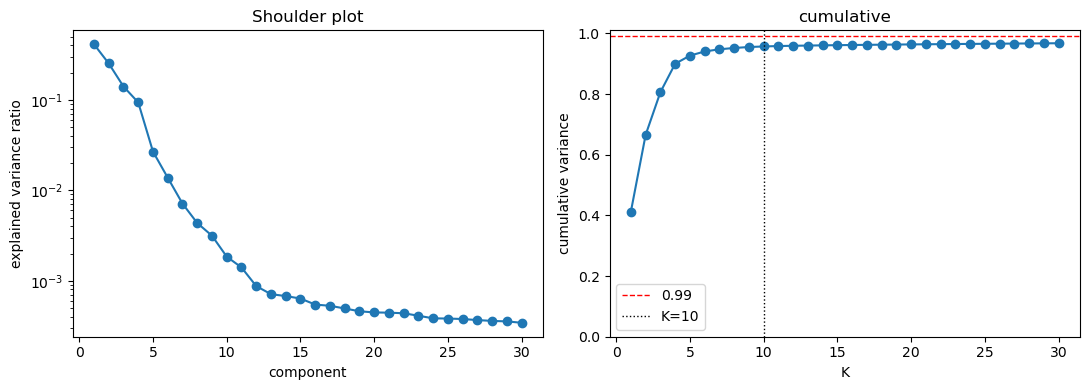

In [8]:
# ---- explained variance: how many components do we actually need? --
ratio = pca.explained_variance_ratio_full.cpu().numpy()
cum   = pca.cumulative_variance().cpu().numpy()
for k in range(1, 16):
    print(f"K={k:2d}   this={ratio[k-1]:.4e}   cumulative={cum[k-1]:.6f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(np.arange(1, 31), ratio[:30], 'o-')
ax[0].set_xlabel('component'); ax[0].set_ylabel('explained variance ratio'); ax[0].set_title('Shoulder plot')
ax[1].plot(np.arange(1, 31), cum[:30], 'o-')
ax[1].axhline(0.99, color='r', ls='--', lw=1, label='0.99')
ax[1].axvline(K, color='k', ls=':', lw=1, label=f'K={K}')
ax[1].set_xlabel('K'); ax[1].set_ylabel('cumulative variance'); ax[1].set_ylim(0, 1.01)
ax[1].legend(); ax[1].set_title('cumulative')
plt.tight_layout()

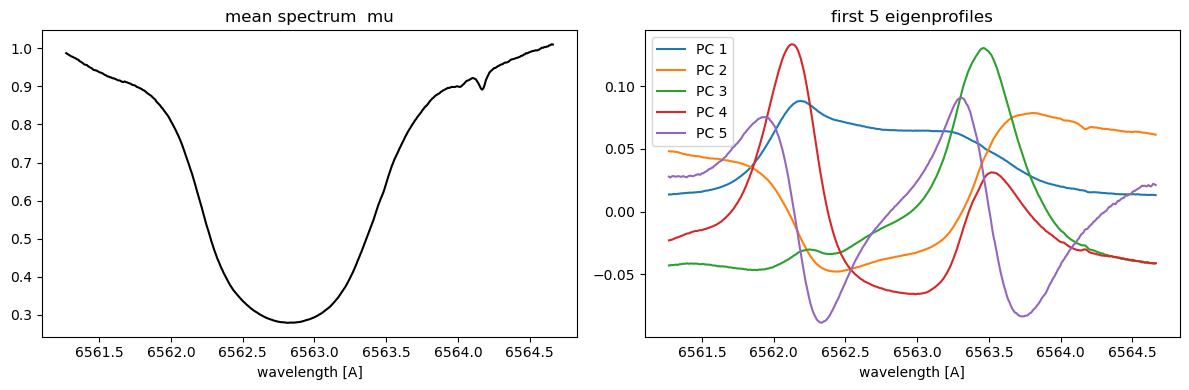

In [10]:
# ---- mean spectrum and the first few eigenprofiles -----------------
mu = pca.mu.cpu().numpy()
V  = pca.components_full.cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(wl, mu, 'k'); ax[0].set_title('mean spectrum  mu'); ax[0].set_xlabel('wavelength [A]')
for i in range(5):
    ax[1].plot(wl, V[i], label=f'PC {i+1}')
ax[1].set_title('first 5 eigenprofiles'); ax[1].set_xlabel('wavelength [A]'); ax[1].legend()
plt.tight_layout()

RMS at K=10: 1.193e-02   (mean |I| = 0.692)


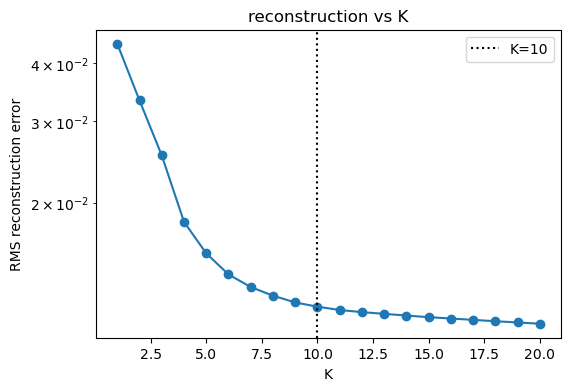

In [11]:
# ---- reconstruction quality vs K on real background spectra --------
# Reproduce exactly what the fit sees: block already cropped, divide by Iqs.
X = torch.from_numpy((blk / Iqs).reshape(-1, blk.shape[-1]).astype(np.float32))
X = X[torch.isfinite(X).all(1)]
gen = torch.Generator().manual_seed(0)
Xs  = X[torch.randperm(X.shape[0], generator=gen)[:20000]]   # subsample for a quick curve

Ks  = np.arange(1, 21)
rms = [float(torch.sqrt(torch.mean((Xs - pca.reconstruct(pca.project(Xs, k=int(k)))) ** 2)))
       for k in Ks]
plt.figure(figsize=(6, 4))
plt.semilogy(Ks, rms, 'o-'); plt.axvline(K, color='k', ls=':', label=f'K={K}')
plt.xlabel('K'); plt.ylabel('RMS reconstruction error'); plt.title('reconstruction vs K'); plt.legend()
print(f"RMS at K={K}: {rms[K-1]:.3e}   (mean |I| = {float(Xs.abs().mean()):.3f})")

grad wrt coefficients OK: True | grad norm: 1.064235789272061e-06


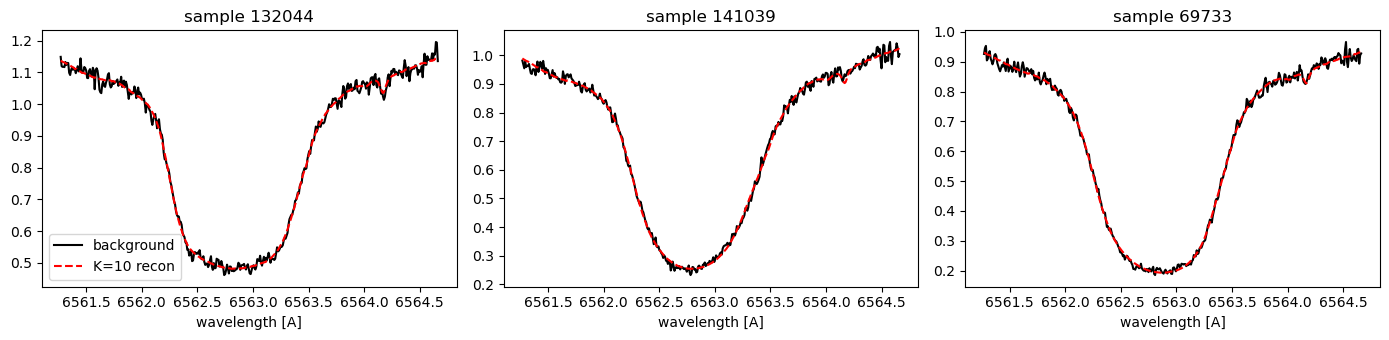

In [12]:
# ---- example reconstructions + confirm the autograd path -----------
torch.manual_seed(0)
sel = torch.randint(0, X.shape[0], (3,))
rec = pca.reconstruct(pca.project(X[sel], k=K))
fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
for j in range(3):
    ax[j].plot(wl, X[sel[j]].numpy(), 'k', label='background')
    ax[j].plot(wl, rec[j].detach().numpy(), 'r--', label=f'K={K} recon')
    ax[j].set_title(f'sample {int(sel[j])}'); ax[j].set_xlabel('wavelength [A]')
ax[0].legend(); plt.tight_layout()

# gradient must flow to the coefficients -- this is what step 2 will optimise
c = nn.Parameter(pca.project(X[sel], k=K))
loss = ((pca.reconstruct(c) - X[sel]) ** 2).sum()
loss.backward()
print("grad wrt coefficients OK:", c.grad is not None, "| grad norm:", float(c.grad.norm()))

## Self-test (no external data)

Validates the module math independently of the MiHI files: the basis is
orthonormal, a project -> reconstruct round-trip recovers data that lives in the
span, and gradients flow. Safe to run on its own.

In [13]:
# ---- standalone self-test ------------------------------------------
torch.manual_seed(0)
L = 60
true_mu = torch.randn(L)
true_B  = torch.linalg.qr(torch.randn(L, 4))[0].T                 # 4 orthonormal rows (4, L)
coef    = torch.randn(2000, 4) * torch.tensor([5., 3., 1., 0.5])
synth   = true_mu + coef @ true_B                                 # data with intrinsic rank 4

p = fit_background_basis(synth, n_snapshots=None, n_components=4)
Vt = p.components_
print("orthonormal V:", torch.allclose(Vt @ Vt.T, torch.eye(4), atol=1e-4))
rec = p.reconstruct(p.project(synth))
print("round-trip (rank-4 data, K=4) max abs err:", float((synth - rec).abs().max()))
print("cumulative variance at K=4:", round(float(p.cumulative_variance()[3]), 6), "(~1.0 expected)")

orthonormal V: True
round-trip (rank-4 data, K=4) max abs err: 1.430511474609375e-06
cumulative variance at K=4: 1.0 (~1.0 expected)
